In [1]:
from fleet_replacement.episode import EpisodeRecord, EpisodeRecorder
from fleet_replacement.envs.fleet_replacement import FleetReplacementEnv
from fleet_replacement.policies import LookaheadAgent
from fleet_replacement.config import load_env_config

config = load_env_config("../configs/env.yaml")
env = EpisodeRecorder(FleetReplacementEnv(config=config))
agent = LookaheadAgent(config)

obs, _ = env.reset(seed=42)
while True:
    obs, reward, terminated, truncated, info = env.step(agent.select_action(obs))
    if terminated or truncated:
        break

record = env.episode_record
df = record.to_dataframe()  # pandas DataFrame, indexed by year
record.save("../results/ep42.pkl")  # persist

# For visualisation:
record.years  # (35,)
record.n_electric  # (35,)
record.actions  # (35, 10)  — heatmap of decisions per slot
record.reward_component("revenue")  # (35,)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\comm

array([31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 30517500.        , 29980162.90778273,
       28497574.49285075, 28339054.59035627, 28255181.6473808 ,
       28217080.91431042, 28533561.69377619, 28789044.79467422,
       28991252.96734741, 29148807.82275542])

In [2]:
df.head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2025,0,8,3.5,18.000000,3.000000,1600000.0,3200000.00,0.711856,15372800.0,31200000.0,1.123200e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.443200e+07,15372800.0
2026,0,8,3.5,18.288383,2.875461,1600000.0,2955045.00,0.715743,15192848.0,31200000.0,1.141195e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.461195e+07,15192848.0
2027,0,8,3.5,18.819195,2.657462,1600000.0,2553818.25,0.720793,14861622.0,31200000.0,1.174318e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.494318e+07,14861622.0
2028,0,8,3.5,19.053183,2.621959,1600000.0,2361374.50,0.727274,14715612.0,31200000.0,1.188919e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.508919e+07,14715612.0
2029,0,8,3.5,18.915342,2.713659,1600000.0,2286878.75,0.735463,14801628.0,31200000.0,1.180317e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.500317e+07,14801628.0


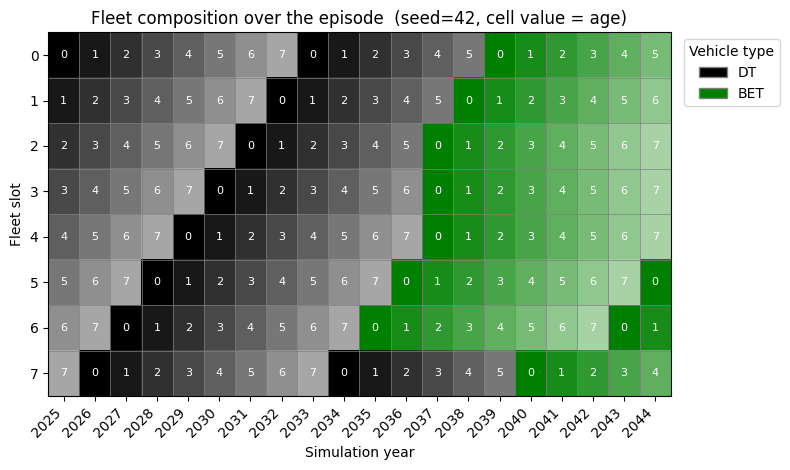

In [3]:
from plot_helpers import plot_episode_fleet_composition

plot_episode_fleet_composition(record)

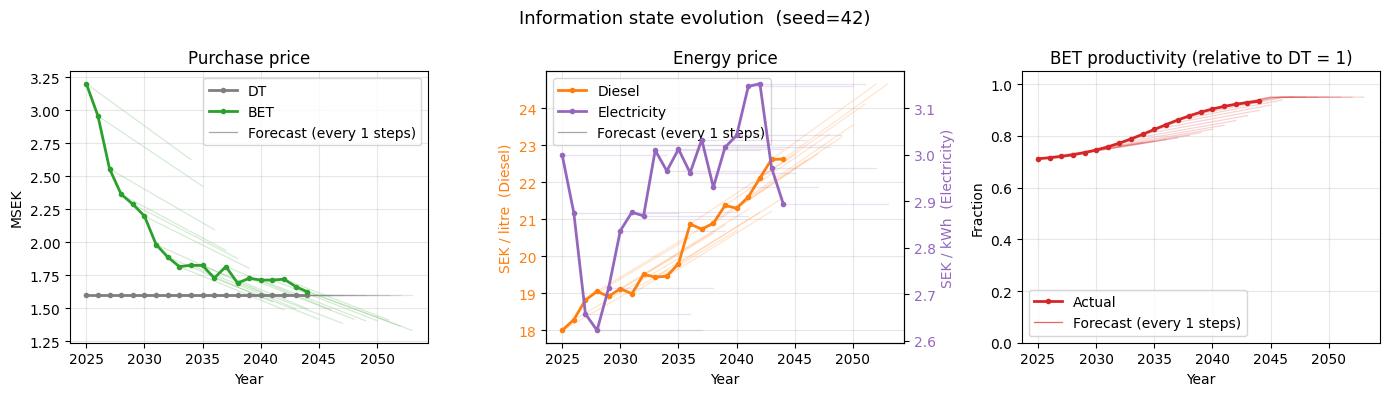

In [4]:
from plot_helpers import plot_episode_information_state

plot_episode_information_state(record, agent)

In [5]:
record.reward_component("sale_result")

array([ 832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        , 2688000.        ,
        960000.        ,  960000.        ,  960000.        ,
             0.        ,       0.        ,  893628.51151727,
        864679.94399501, 2531509.65689788])